## Get and filter data

In [1]:
# get airport route data
import pandas as pd

cols = [
    'year', 'month',
    'origin_iata', 'origin_airport_id', 'origin_wac', 'origin_city',
    'dest_iata', 'dest_airport_id', 'dest_wac', 'dest_city',
    'carrier_iata', 'carrier_entity_code', 'carrier_group',
    'distance', 'service_class',
    'aircraft_group', 'aircraft_type', 'aircraft_config',
    'departures_performed', 'departures_scheduled',
    'payload', 'seats', 'col22', 'col23', 'col24',
    'passengers', 'col26',
    'freight', 'mail',
    'ramp_to_ramp', 'air_time',
    'carrier_wac'
]

# Read in the data
df = pd.read_csv(
    'Data Bank 28DS - T-100 Domestic Segment Data 2025.asc',
    sep='|', header=None, index_col=False, names=cols
)

# Filter to 3-letter IATA codes for origin and destination; get non-zero passenger data
df = df[
    df['origin_iata'].str.match(r'^[A-Z]{3}$') &
    df['dest_iata'].str.match(r'^[A-Z]{3}$') &
    (df['passengers'] > 0)
]

# Aggregate to route level to get edges of the network
edges = df.groupby(['origin_iata', 'dest_iata']).agg(
    passengers=('passengers', 'sum'),
    departures=('departures_performed', 'sum')
).reset_index()

In [2]:
df

,year,month,origin_iata,origin_airport_id,origin_wac,origin_city,dest_iata,dest_airport_id,dest_wac,dest_city,...,col22,col23,col24,passengers,col26,freight,mail,ramp_to_ramp,air_time,carrier_wac
671,2025,1,AAF,30122,33,"Apalachicola, FL",OCF,33809,33,"Ocala, FL",...,3,0,0,48,42,10,NaN,NaN,NaN,NaN
672,2025,10,AAF,30122,33,"Apalachicola, FL",PBI,34027,33,"West Palm Beach/Palm Beach, FL",...,2,0,0,102,90,10,NaN,NaN,NaN,NaN
673,2025,2,AAF,30122,33,"Apalachicola, FL",SUA,35030,33,"Stuart, FL",...,4,0,0,96,78,10,NaN,NaN,NaN,NaN
674,2025,12,ABE,30135,23,"Allentown/Bethlehem/Easton, PA",ABE,30135,23,"Allentown/Bethlehem/Easton, PA",...,40,0,0,66,24,10,NaN,NaN,NaN,NaN
675,2025,7,ABE,30135,23,"Allentown/Bethlehem/Easton, PA",ACK,30154,13,"Nantucket, MA",...,7,0,0,108,66,10,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454466,2025,8,ZXU,36353,15,"North Kingstown, RI",BHB,30589,12,"Bar Harbor, ME",...,6,0,0,78,66,10,NaN,NaN,NaN,NaN
454467,2025,7,ZXU,36353,15,"North Kingstown, RI",BID,30613,15,"Block Island, RI",...,6,0,0,24,18,10,NaN,NaN,NaN,NaN
454468,2025,11,ZXU,36353,15,"North Kingstown, RI",JGG,33667,38,"Williamsburg, VA",...,9,0,0,126,102,10,NaN,NaN,NaN,NaN
454469,2025,12,ZXU,36353,15,"North Kingstown, RI",TEB,35167,21,"Teterboro, NJ",...,1,0,0,66,42,10,NaN,NaN,NaN,NaN


In [3]:
print(edges.sort_values('passengers', ascending=False).head(10))

      origin_iata dest_iata  passengers  departures
13955         JFK       LAX     3741445       10181
15312         LAX       JFK     3220713       10134
14012         JFK       SFO     2569997        6630
25657         SFO       JFK     2175480        6593
15297         LAX       HNL     2053774        5997
20611         ORD       LAX     1897225        7176
8906          EWR       LAX     1892528        5270
11494         HNL       LAX     1860318        5784
15890         LGA       ORD     1823605       11216
3921          BOS       SFO     1780992        4547


In [4]:
# get airport location data
airports = pd.read_csv(
    'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat',
    header=None,
    names=['airport_id','name','city','country','iata','icao',
           'lat','lon','altitude','timezone','dst','tz_database','type','source']
)

# get airports with 3-letter IATA code and are located in USA
airports = airports[(airports['iata'] != '\\N') & (airports['country'] == 'United States')][['iata','name','lat','lon']].reset_index(drop=True)

airports

,iata,name,lat,lon
0,BTI,Barter Island LRRS Airport,70.134003,-143.582001
1,LUR,Cape Lisburne LRRS Airport,68.875099,-166.110001
2,PIZ,Point Lay LRRS Airport,69.732903,-163.005005
3,ITO,Hilo International Airport,19.721399,-155.048004
4,ORL,Orlando Executive Airport,28.545500,-81.332901
...,...,...,...,...
1246,CLP,Clarks Point Airport,58.833698,-158.529007
1247,RDB,Red Dog Airport,68.032097,-162.899002
1248,SOV,Seldovia Airport,59.442402,-151.703995
1249,VDI,Vidalia Regional Airport,32.192699,-82.371201


## Build Graph

In [5]:
# Graph
import networkx as nx
import pandas as pd
import numpy as np

# Build weighted graph from edge list
G = nx.Graph()
for _, row in edges.iterrows():
    G.add_edge(row['origin_iata'], row['dest_iata'], weight=row['passengers'])

# Get largest connected graph
lcc_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc_nodes).copy()

# dictionary of airport codes to lon/lat for mapping
pos = {row['iata']: (row['lon'], row['lat'])
       for _, row in airports.iterrows()
       if row['iata'] in G.nodes()}

# number of nodes and edges
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Is connected: {nx.is_connected(G)}")

Nodes: 1203
Edges: 19001
Is connected: True


In [6]:
# group nodes into communities

from networkx.algorithms.community import louvain_communities
# Louvain is used instead of Girvan-Newman because Louvain is faster

communities = louvain_communities(G, weight='weight', seed=42)
# Assign community label to each node
node_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_community[node] = i



print(f"Number of communities: {len(communities)}")

Number of communities: 13


In [9]:
# get key node metrics

# how often a node sits on the shortest path between two other nodes
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)

# total passengers per airport: node strength
strength = {node: sum(d['weight'] for _, _, d in G.edges(node, data=True))
            for node in G.nodes()}

In [12]:
total_passengers = sum(strength.values())
top_airports = pd.Series(strength).sort_values(ascending=False)
print(top_airports.head(20))
print(f"Top 5 handle: {top_airports.head(5).sum() / total_passengers * 100:.1f}%")
print(f"Top 10 handle: {top_airports.head(10).sum() / total_passengers * 100:.1f}%")

ORD    49368081
DEN    47359615
DFW    45665705
ATL    42329279
LAX    40133743
SEA    34126475
PHX    30723430
LAS    30560139
CLT    28002925
SFO    27341455
MCO    26900820
IAH    25315258
BOS    24820454
JFK    24667461
EWR    23520889
LGA    22879245
MIA    21690497
MSP    20424459
PHL    18661800
DTW    17938579
dtype: int64
Top 5 handle: 18.9%
Top 10 handle: 31.5%


## Visualize

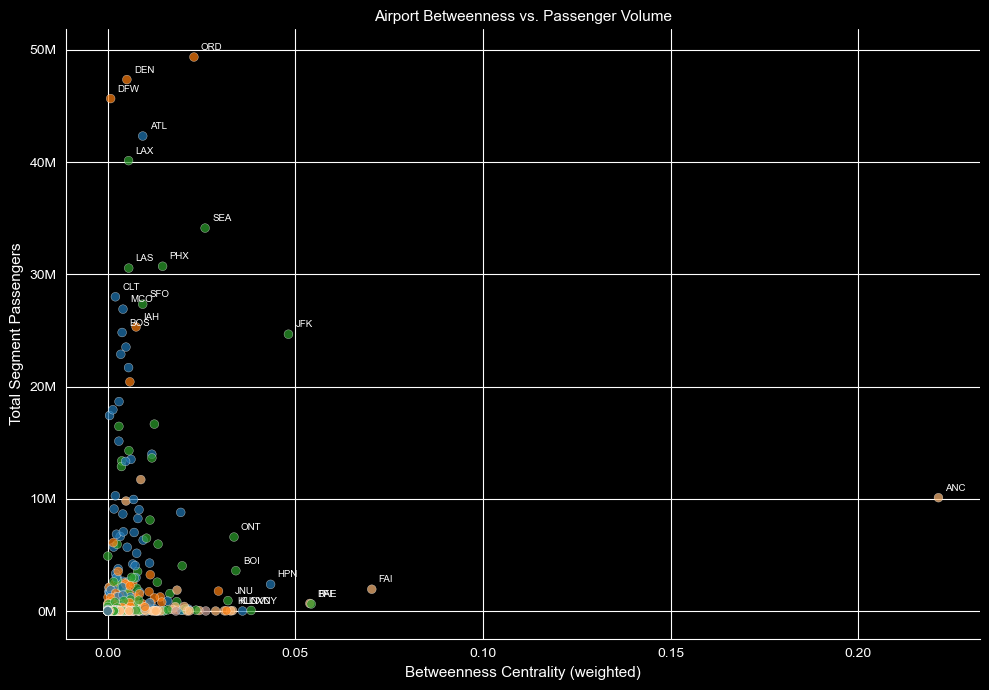

In [11]:
# airport volume vs. betweenness

import matplotlib.pyplot as plt
import numpy as np

nodes = list(G.nodes())
x = np.array([betweenness[n] for n in nodes])
y = np.array([strength[n] for n in nodes])

cmap = plt.get_cmap('tab20')
colors_scatter = [cmap(node_community[n]) for n in nodes]

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(x, y, c=colors_scatter, alpha=0.7, s=40,
           edgecolors='white', linewidths=0.3)

# Label notable airports — high betweenness or high strength
threshold_bet = np.percentile(x, 99)
threshold_str = np.percentile(y, 99)
for n, xi, yi in zip(nodes, x, y):
    if xi >= threshold_bet or yi >= threshold_str:
        ax.annotate(n, (xi, yi), fontsize=7,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Betweenness Centrality (weighted)', fontsize=11)
ax.set_ylabel('Total Segment Passengers', fontsize=11)
ax.set_title('Airport Betweenness vs. Passenger Volume', fontsize=11)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e6:.0f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

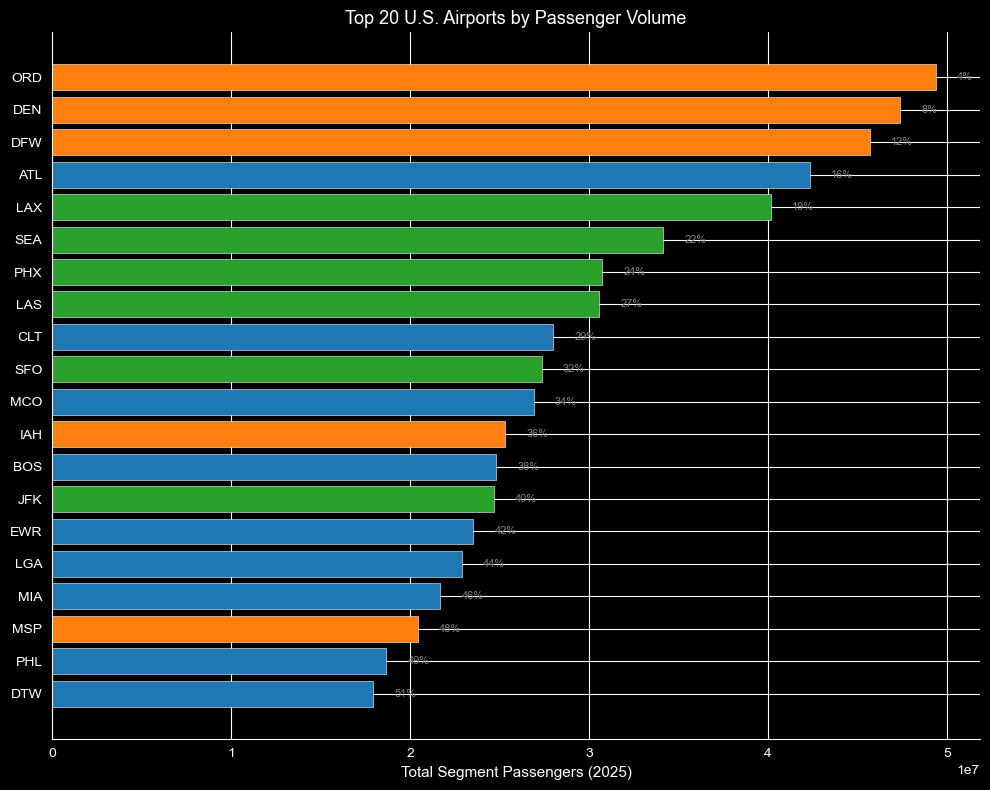

In [18]:
# 20 busiest airports, color coded by community

import matplotlib.pyplot as plt

top_n = 20
top_airports_df = pd.DataFrame({
    'iata': top_airports.head(top_n).index,
    'passengers': top_airports.head(top_n).values,
    'community': [node_community[iata] for iata in top_airports.head(top_n).index]
})

fig, ax = plt.subplots(figsize=(10, 8))

colors = [cmap(c) for c in top_airports_df['community']]
bars = ax.barh(top_airports_df['iata'], top_airports_df['passengers'],
               color=colors, edgecolor='white', linewidth=0.4)

ax.invert_yaxis()
ax.set_xlabel('Total Segment Passengers (2025)', fontsize=11)
ax.set_title('Top 20 U.S. Airports by Passenger Volume', fontsize=13)

# Annotate cumulative passenger share
cumulative = top_airports_df['passengers'].cumsum() / total_passengers * 100
for i, (val, cum) in enumerate(zip(top_airports_df['passengers'], cumulative)):
    ax.text(val + total_passengers * 0.001, i, f'{cum:.0f}%',
            va='center', fontsize=8, color='gray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

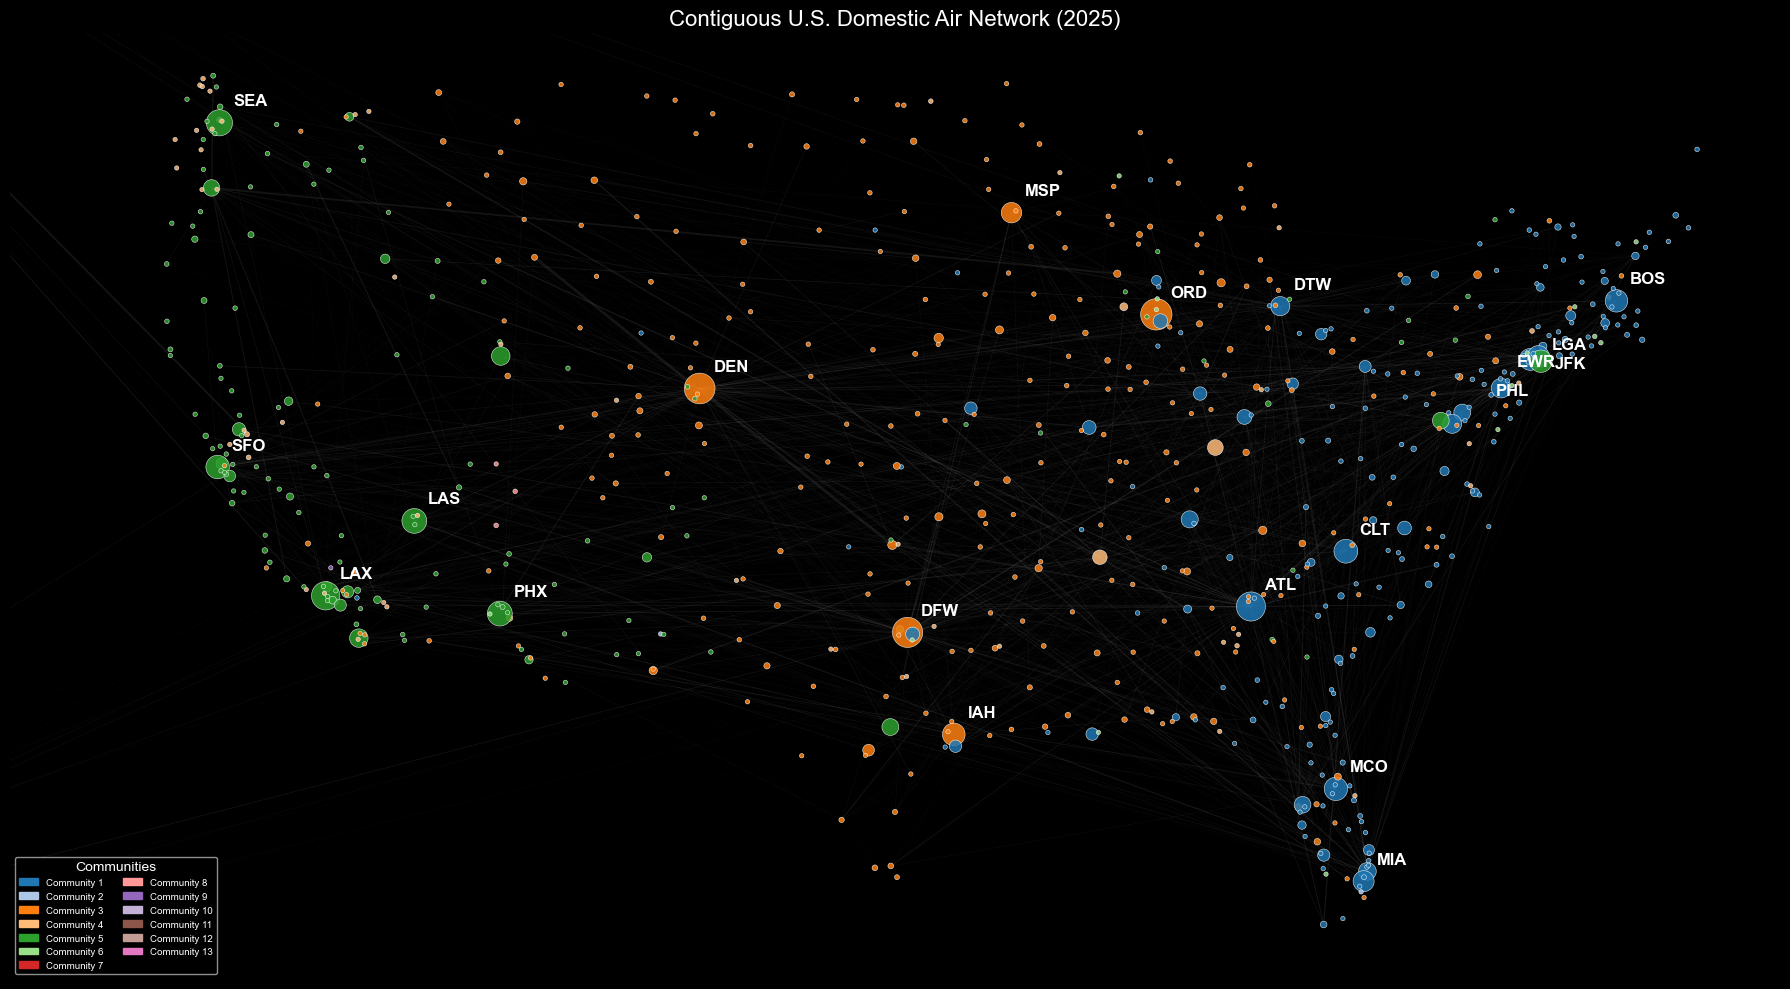

In [15]:
# geographic network map. Hawaii and Alaska excluded

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import numpy as np

cmap = plt.get_cmap('tab20')

fig, ax = plt.subplots(figsize=(18, 10))

# Edges
edge_weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
edge_weights_norm = edge_weights / edge_weights.max()
segs = [(pos[u], pos[v]) for u, v in G.edges() if u in pos and v in pos]
lc = LineCollection(segs, linewidths=edge_weights_norm * 2,
                    alpha=0.15, color='gray', zorder=1)
ax.add_collection(lc)

# Nodes
node_list = [n for n in G.nodes() if n in pos]
xy = np.array([pos[n] for n in node_list])
colors = [cmap(node_community[n]) for n in node_list]
sizes = np.array([strength[n] for n in node_list])
sizes = (sizes / sizes.max()) * 500 + 10

ax.scatter(xy[:,0], xy[:,1], c=colors, s=sizes,
           alpha=0.85, zorder=2, edgecolors='white', linewidths=0.4)

custom_offsets = {
    'JFK': (0.5, -0.2),
    'LGA': (0.5, 0.2),
    'EWR': (-0.5, -0.2),
    'PHL': (-0.2,-0.2),
}

top20 = top_airports.head(20).index.tolist()
for iata in top20:
    if iata in pos:
        lon, lat = pos[iata]
        lon_off, lat_off = custom_offsets.get(iata, (0.5, 0.5))
        ax.text(lon + lon_off, lat + lat_off, iata, fontsize=12,
                fontweight='bold', color='white', zorder=3)

# Legend
num_communities = len(set(node_community.values()))
patches = [mpatches.Patch(color=cmap(i), label=f'Community {i+1}')
           for i in range(num_communities)]
ax.legend(handles=patches, loc='lower left', fontsize=7,
          ncol=2, framealpha=0.7, title='Communities')

ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
ax.axis('off')
ax.set_title('Contiguous U.S. Domestic Air Network (2025)', fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# folium map showing top 1000 edges in network

import folium
import pandas as pd
import numpy as np

# Top N edges by passenger volume to avoid clutter
TOP_N_EDGES = 1000
top_edges = edges.sort_values('passengers', ascending=False).head(TOP_N_EDGES)

# Normalize strength for node sizing
strength_series = pd.Series(strength)
max_strength = strength_series.max()

# Initialize map centered on contiguous US
m = folium.Map(location=[39.5, -98.35], zoom_start=4,
               tiles='CartoDB positron')

# Draw edges first (so nodes render on top)
for _, row in top_edges.iterrows():
    origin = row['origin_iata']
    dest = row['dest_iata']

    if origin not in pos or dest not in pos:
        continue

    lon1, lat1 = pos[origin]
    lon2, lat2 = pos[dest]

    # Normalize weight for line opacity
    weight_norm = row['passengers'] / top_edges['passengers'].max()

    folium.PolyLine(
        locations=[[lat1, lon1], [lat2, lon2]],
        weight=max(0.4, weight_norm * 5),
        color='#4a90d9',
        opacity=max(0.1, weight_norm * 0.8),
        tooltip=f"{origin} → {dest}: {int(row['passengers']):,} passengers"
    ).add_to(m)

# Draw nodes
for iata, (lon, lat) in pos.items():
    if iata not in strength:
        continue

    s = strength[iata]
    # Scale radius: min 2, max 20
    radius = 2 + (s / max_strength) * 18

    # Get airport name for tooltip
    name_match = airports[airports['iata'] == iata]['name']
    name = name_match.values[0] if len(name_match) > 0 else iata

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color='white',
        weight=0.5,
        fill=True,
        fill_color='#e87c2e',
        fill_opacity=0.85,
        tooltip=f"<b>{iata}</b> — {name}<br>Passengers: {s:,.0f}"
    ).add_to(m)

m.save('airport_network.html')
print("Saved to airport_network.html")

Saved to airport_network.html
